# 04 — Customer Segmentation: RFM Analysis & CLV Estimation
## Decision Intelligence System · Olist E-Commerce Dataset

**Objective:** Segment all customers using the industry-standard **RFM framework** and estimate **Customer Lifetime Value (CLV)** to identify who to invest in, retain, and re-engage.

### What is RFM?
| Dimension | Question | Higher = Better? |
|---|---|---|
| **R**ecency | How recently did the customer buy? | Lower days = better |
| **F**requency | How many times have they bought? | Higher = better |
| **M**onetary | How much have they spent in total? | Higher = better |

Each customer gets scored 1–5 on each dimension → combined into a segment label.

**Input:** `master_olist.csv` from Notebook 01  
**Output:** RFM segments, CLV estimates, charts saved to `outputs/`

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Paths
DATA_PATH    = '../data/'
OUTPUTS_PATH = '../outputs/'
os.makedirs(DATA_PATH,    exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
TEAL   = '#5DCAA5'
PINK   = '#D4537E'

# Segment color map — used consistently across all charts
SEGMENT_COLORS = {
    'Champions'          : GREEN,
    'Loyal Customers'    : BLUE,
    'Potential Loyalists': TEAL,
    'Recent Customers'   : AMBER,
    'At Risk'            : CORAL,
    'Churned'            : PURPLE,
    'Others'             : '#adb5bd'
}

print('Setup complete!')

Setup complete!


## 2. Load Data & Prepare Customer Table

In [2]:
master = pd.read_csv(DATA_PATH + 'master_olist.csv', low_memory=False)

for col in ['order_purchase_timestamp', 'order_delivered_customer_date']:
    master[col] = pd.to_datetime(master[col], errors='coerce')

# Keep only delivered orders — these are confirmed revenue
delivered = master[master['order_status'] == 'delivered'].copy()

# Reference date for recency = 1 day after last order in dataset
REFERENCE_DATE = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f'Delivered orders  : {len(delivered):,}')
print(f'Unique customers  : {delivered["customer_unique_id"].nunique():,}')
print(f'Reference date    : {REFERENCE_DATE.date()} (for recency calculation)')

Delivered orders  : 110,197
Unique customers  : 93,358
Reference date    : 2018-08-30 (for recency calculation)


## 3. Build RFM Base Table

In [3]:
rfm_base = (
    delivered
    .groupby('customer_unique_id')
    .agg(
        last_order_date = ('order_purchase_timestamp', 'max'),
        frequency       = ('order_id',                'nunique'),
        monetary        = ('total_payment',            'sum'),
        first_order     = ('order_purchase_timestamp', 'min'),
        avg_review      = ('review_score',             'mean'),
        customer_state  = ('customer_state',           'first')
    )
    .reset_index()
)

# Recency = days since last purchase
rfm_base['recency'] = (
    REFERENCE_DATE - rfm_base['last_order_date']
).dt.days

# Customer lifespan in days
rfm_base['lifespan_days'] = (
    rfm_base['last_order_date'] - rfm_base['first_order']
).dt.days + 1

# Average order value
rfm_base['avg_order_value'] = rfm_base['monetary'] / rfm_base['frequency']

print(f'RFM base table: {rfm_base.shape}')
print()
print('RFM Descriptive Statistics:')
rfm_base[['recency','frequency','monetary','avg_order_value']].describe().round(2)

RFM base table: (93358, 10)

RFM Descriptive Statistics:


,recency,frequency,monetary,avg_order_value
count,93358.00,93358.00,93358.00,93358.00
mean,237.94,1.03,211.83,204.58
std,152.59,0.21,642.16,619.61
min,1.00,1.00,0.00,0.00
25%,114.00,1.00,63.76,63.10
50%,219.00,1.00,112.95,110.40
75%,346.00,1.00,201.74,195.60
max,714.00,15.00,109312.64,109312.64


## 4. Score Each Customer (1–5 on R, F, M)

In [4]:
# R score: lower recency = more recent = better = score 5
rfm_base['r_score'] = pd.qcut(
    rfm_base['recency'], q=5,
    labels=[5, 4, 3, 2, 1]  # reversed: low recency days = score 5
).astype(int)

# F score: higher frequency = better = score 5
# Use rank to handle ties (most customers buy only once)
rfm_base['f_score'] = pd.qcut(
    rfm_base['frequency'].rank(method='first'), q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# M score: higher monetary = better = score 5
rfm_base['m_score'] = pd.qcut(
    rfm_base['monetary'], q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combined RFM score (weighted: R=0.3, F=0.3, M=0.4)
rfm_base['rfm_score'] = (
    rfm_base['r_score'] * 0.3 +
    rfm_base['f_score'] * 0.3 +
    rfm_base['m_score'] * 0.4
).round(2)

print('RFM scores assigned!')
print(rfm_base[['r_score','f_score','m_score','rfm_score']].describe().round(2))

RFM scores assigned!
       r_score  f_score  m_score  rfm_score
count 93358.00 93358.00 93358.00   93358.00
mean      3.00     3.00     3.00       3.00
std       1.41     1.41     1.41       0.84
min       1.00     1.00     1.00       1.00
25%       2.00     2.00     2.00       2.40
50%       3.00     3.00     3.00       3.00
75%       4.00     4.00     4.00       3.60
max       5.00     5.00     5.00       5.00


## 5. Assign Customer Segments

In [5]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Churned'
    else:
        return 'Others'

rfm_base['segment'] = rfm_base.apply(assign_segment, axis=1)

segment_summary = (
    rfm_base.groupby('segment')
    .agg(
        customer_count = ('customer_unique_id', 'count'),
        avg_recency    = ('recency',    'mean'),
        avg_frequency  = ('frequency',  'mean'),
        avg_monetary   = ('monetary',   'mean'),
        total_revenue  = ('monetary',   'sum'),
        avg_review     = ('avg_review', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
).round(1)
segment_summary['customer_pct'] = (
    segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100
).round(1)

print('Segment Summary:')
print(segment_summary[[
    'segment','customer_count','customer_pct',
    'avg_recency','avg_frequency','avg_monetary',
    'revenue_pct','avg_review'
]].to_string(index=False))

Segment Summary:
            segment  customer_count  customer_pct  avg_recency  avg_frequency  avg_monetary  revenue_pct  avg_review
            At Risk           22230         23.80       394.66           1.05        212.11        23.80        4.17
    Loyal Customers           27325         29.30       144.18           1.03        165.71        22.90        4.13
            Churned           14986         16.10       395.51           1.00        214.80        16.30        4.18
   Recent Customers           14984         16.10        90.88           1.00        204.36        15.50        4.20
          Champions            6460          6.90        91.05           1.18        442.08        14.40        4.14
Potential Loyalists            4353          4.70       220.50           1.00        282.55         6.20        3.93
             Others            3020          3.20       219.86           1.00         55.03         0.80        4.17


## 6. Chart 1 — Segment Size & Revenue Share

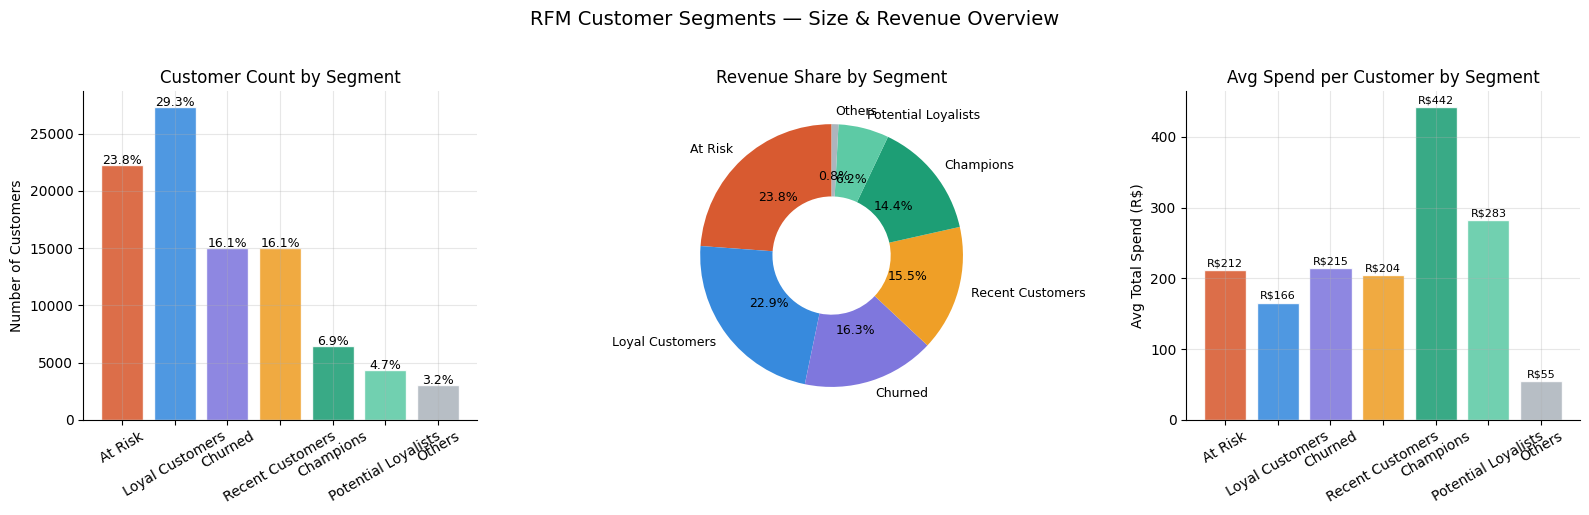

Chart saved!


In [6]:
seg_order = segment_summary['segment'].tolist()
colors    = [SEGMENT_COLORS.get(s, '#adb5bd') for s in seg_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Customer count
bars0 = axes[0].bar(seg_order, segment_summary['customer_count'],
                    color=colors, edgecolor='white', alpha=0.88)
for bar, pct in zip(bars0, segment_summary['customer_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Customer Count by Segment', fontsize=12)
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

# Revenue share donut
axes[1].pie(
    segment_summary['total_revenue'],
    labels=seg_order,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9)
)
axes[1].set_title('Revenue Share by Segment', fontsize=12)

# Avg monetary per segment
bars2 = axes[2].bar(seg_order, segment_summary['avg_monetary'],
                    color=colors, edgecolor='white', alpha=0.88)
for bar, val in zip(bars2, segment_summary['avg_monetary']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'R${val:.0f}', ha='center', fontsize=8)
axes[2].set_title('Avg Spend per Customer by Segment', fontsize=12)
axes[2].set_ylabel('Avg Total Spend (R$)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('RFM Customer Segments — Size & Revenue Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'rfm_segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 7. Chart 2 — RFM Score Distribution per Segment

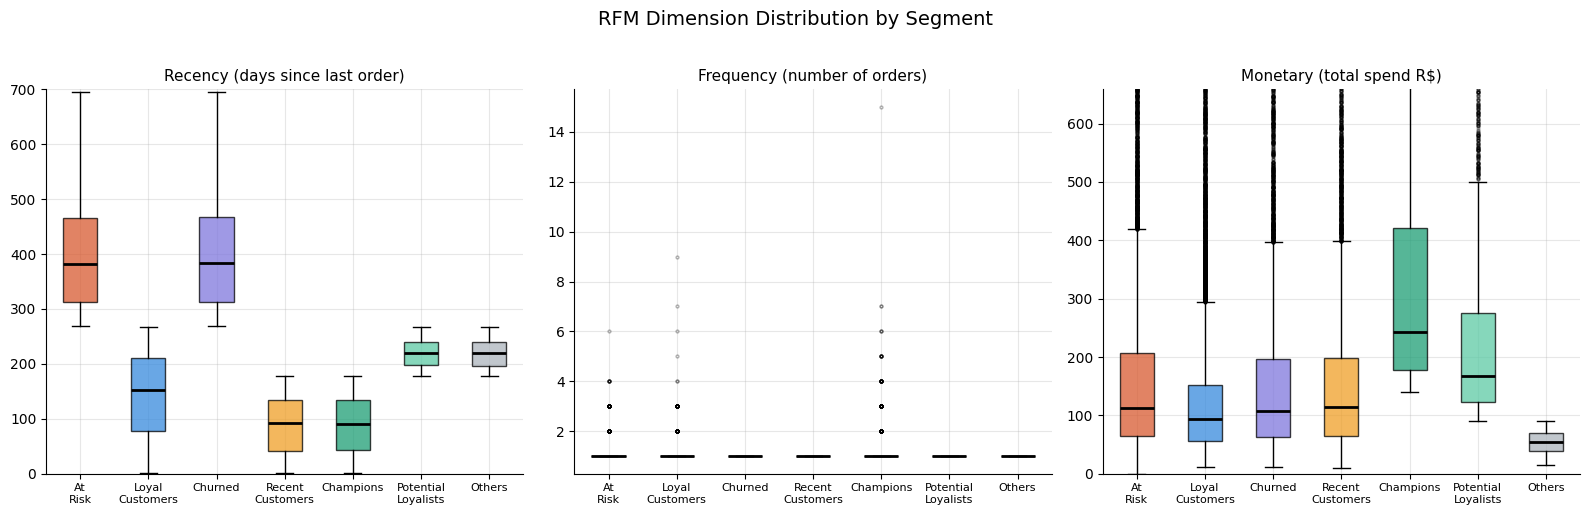

Chart saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [
    ('recency',    'Recency (days since last order)', True),   # lower = better
    ('frequency',  'Frequency (number of orders)',    False),
    ('monetary',   'Monetary (total spend R$)',        False)
]

for ax, (metric, label, invert) in zip(axes, metrics):
    seg_vals = [
        rfm_base[rfm_base['segment'] == seg][metric].dropna().values
        for seg in seg_order
    ]
    bp = ax.boxplot(
        seg_vals,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(
        [s.replace(' ', '\n') for s in seg_order],
        fontsize=8
    )
    ax.set_title(label, fontsize=11)
    if metric == 'monetary':
        ax.set_ylim(0, rfm_base['monetary'].quantile(0.95))
    if metric == 'recency':
        ax.set_ylim(0, 700)

plt.suptitle('RFM Dimension Distribution by Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'rfm_dimension_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 8. Chart 3 — RFM Heatmap (R vs F Score)

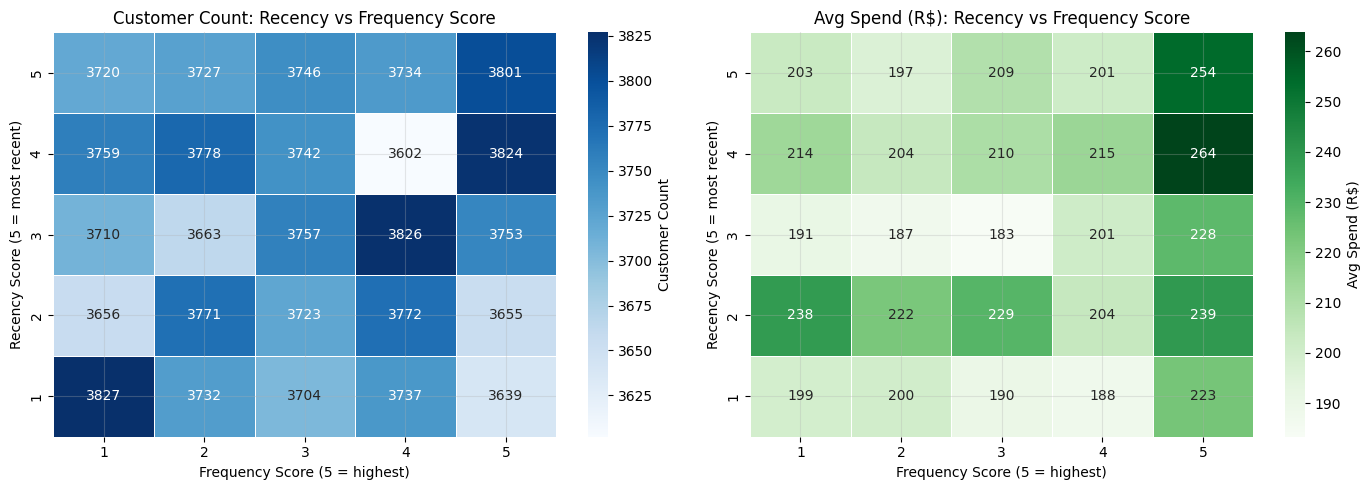

Chart saved!

Insight: Top-right cell (R=5, F=5) = Champions — most recent AND most frequent buyers


In [8]:
# Build heatmap: count of customers at each R-F combination
heatmap_data = (
    rfm_base
    .groupby(['r_score', 'f_score'])
    .agg(
        customer_count = ('customer_unique_id', 'count'),
        avg_monetary   = ('monetary', 'mean')
    )
    .reset_index()
)

pivot_count = heatmap_data.pivot(
    index='r_score', columns='f_score', values='customer_count'
).fillna(0)

pivot_money = heatmap_data.pivot(
    index='r_score', columns='f_score', values='avg_monetary'
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_count.sort_index(ascending=False),
    annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5, ax=axes[0],
    cbar_kws={'label': 'Customer Count'}
)
axes[0].set_title('Customer Count: Recency vs Frequency Score', fontsize=12)
axes[0].set_xlabel('Frequency Score (5 = highest)')
axes[0].set_ylabel('Recency Score (5 = most recent)')

sns.heatmap(
    pivot_money.sort_index(ascending=False),
    annot=True, fmt='.0f', cmap='Greens',
    linewidths=0.5, ax=axes[1],
    cbar_kws={'label': 'Avg Spend (R$)'}
)
axes[1].set_title('Avg Spend (R$): Recency vs Frequency Score', fontsize=12)
axes[1].set_xlabel('Frequency Score (5 = highest)')
axes[1].set_ylabel('Recency Score (5 = most recent)')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print('\nInsight: Top-right cell (R=5, F=5) = Champions — most recent AND most frequent buyers')

## 9. Chart 4 — Segment Review Score & Loyalty

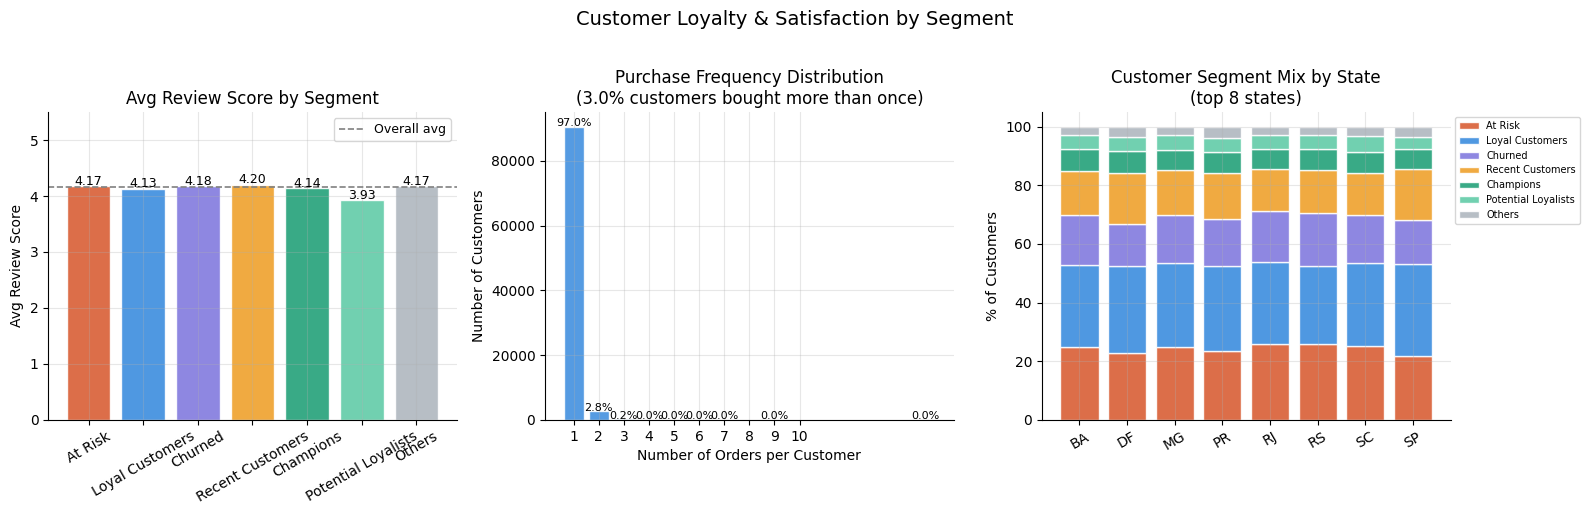

Chart saved!

Repeat purchase rate: 3.00%
Single-purchase customers: 97.0%


In [9]:
# Repeat purchase rate overall
repeat_customers = (rfm_base['frequency'] > 1).sum()
total_customers  = len(rfm_base)
repeat_rate      = repeat_customers / total_customers * 100

# Review score per segment
review_by_seg = rfm_base.groupby('segment')['avg_review'].mean().reset_index()
review_by_seg = review_by_seg.set_index('segment').reindex(seg_order).reset_index()

# Frequency distribution
freq_dist = rfm_base['frequency'].value_counts().sort_index().head(10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Review score by segment
bars = axes[0].bar(
    review_by_seg['segment'],
    review_by_seg['avg_review'],
    color=[SEGMENT_COLORS.get(s, '#adb5bd') for s in review_by_seg['segment']],
    edgecolor='white', alpha=0.88
)
for bar, val in zip(bars, review_by_seg['avg_review']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=9)
axes[0].axhline(rfm_base['avg_review'].mean(), color='gray',
                linewidth=1.2, linestyle='--', label='Overall avg')
axes[0].set_title('Avg Review Score by Segment', fontsize=12)
axes[0].set_ylabel('Avg Review Score')
axes[0].set_ylim(0, 5.5)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# Purchase frequency distribution
axes[1].bar(freq_dist.index, freq_dist.values,
            color=BLUE, edgecolor='white', alpha=0.85)
for bar, val in zip(axes[1].patches, freq_dist.values):
    pct = val / total_customers * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=8)
axes[1].set_title(f'Purchase Frequency Distribution\n({repeat_rate:.1f}% customers bought more than once)', fontsize=12)
axes[1].set_xlabel('Number of Orders per Customer')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(range(1, 11))

# Segment by state (top 10 states)
top10_states = (
    rfm_base.groupby('customer_state')['customer_unique_id']
    .count().nlargest(8).index.tolist()
)
state_seg = (
    rfm_base[rfm_base['customer_state'].isin(top10_states)]
    .groupby(['customer_state', 'segment'])
    .size()
    .unstack(fill_value=0)
)
state_seg_pct = state_seg.div(state_seg.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(state_seg_pct))
for seg in seg_order:
    if seg in state_seg_pct.columns:
        axes[2].bar(
            state_seg_pct.index,
            state_seg_pct[seg],
            bottom=bottom,
            color=SEGMENT_COLORS.get(seg, '#adb5bd'),
            label=seg, edgecolor='white', alpha=0.88
        )
        bottom += state_seg_pct[seg].values
axes[2].set_title('Customer Segment Mix by State\n(top 8 states)', fontsize=12)
axes[2].set_ylabel('% of Customers')
axes[2].legend(fontsize=7, bbox_to_anchor=(1, 1))
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Customer Loyalty & Satisfaction by Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'rfm_loyalty_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f'\nRepeat purchase rate: {repeat_rate:.2f}%')
print(f'Single-purchase customers: {100-repeat_rate:.1f}%')

## 10. Customer Lifetime Value (CLV) Estimation

In [10]:
# CLV formula:
# CLV = Avg Order Value × Purchase Frequency per year × Expected Customer Lifespan (years)
#
# Since most customers buy once, we estimate:
# - Purchase frequency per year = annual orders per customer
# - Lifespan = 3 years (standard e-commerce assumption)

LIFESPAN_YEARS = 3

# Dataset covers ~2 years → annualise frequency
dataset_years = (
    delivered['order_purchase_timestamp'].max() -
    delivered['order_purchase_timestamp'].min()
).days / 365

rfm_base['annual_frequency'] = rfm_base['frequency'] / dataset_years
rfm_base['clv_estimate']     = (
    rfm_base['avg_order_value'] *
    rfm_base['annual_frequency'] *
    LIFESPAN_YEARS
)

# CLV by segment
clv_by_segment = (
    rfm_base.groupby('segment')
    .agg(
        avg_clv          = ('clv_estimate',    'mean'),
        median_clv       = ('clv_estimate',    'median'),
        total_clv        = ('clv_estimate',    'sum'),
        customer_count   = ('customer_unique_id', 'count'),
        avg_order_value  = ('avg_order_value', 'mean'),
        annual_freq      = ('annual_frequency','mean')
    )
    .reset_index()
    .sort_values('avg_clv', ascending=False)
)

print(f'Dataset spans: {dataset_years:.1f} years')
print(f'CLV assumption: {LIFESPAN_YEARS}-year customer lifespan')
print()
print('CLV by Segment:')
print(clv_by_segment[[
    'segment','customer_count','avg_clv','median_clv','total_clv','avg_order_value'
]].to_string(index=False))

Dataset spans: 2.0 years
CLV assumption: 3-year customer lifespan

CLV by Segment:
            segment  customer_count  avg_clv  median_clv  total_clv  avg_order_value
          Champions            6460   678.93      371.93 4385873.95           392.07
Potential Loyalists            4353   433.93      256.78 1888889.41           282.55
            Churned           14986   329.88      165.85 4943629.55           214.80
            At Risk           22230   325.75      172.33 7241433.94           202.62
   Recent Customers           14984   313.85      174.22 4702680.60           204.36
    Loyal Customers           27325   254.48      143.53 6953796.79           160.49
             Others            3020    84.51       84.35  255218.45            55.03


## 11. Chart 5 — CLV by Segment

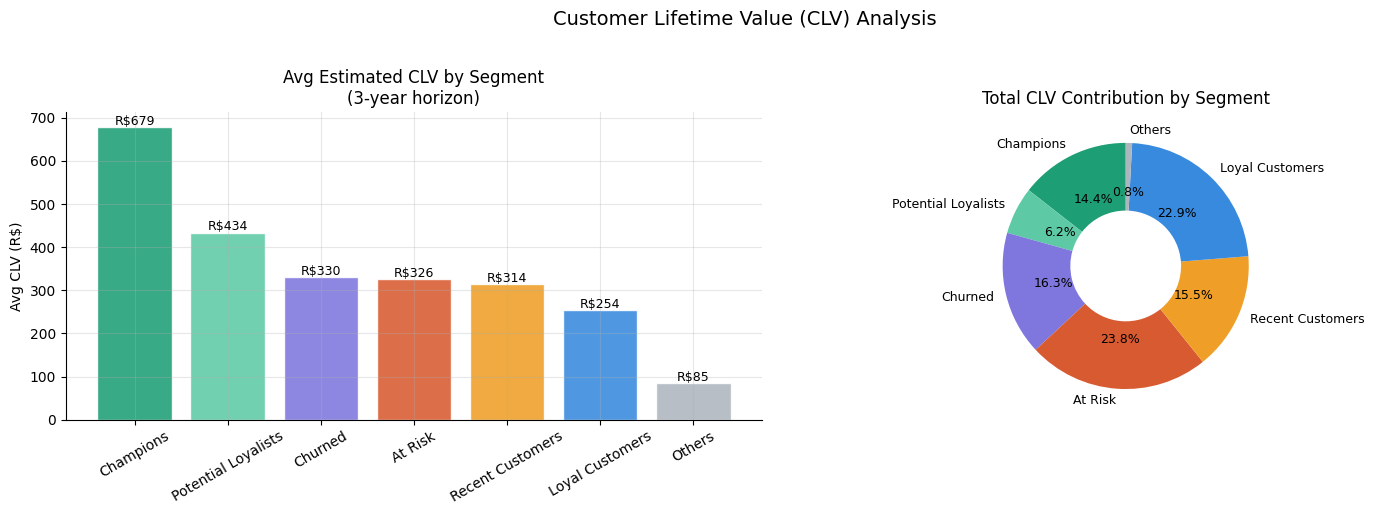

Chart saved!

Total estimated CLV across all customers: R$ 30,371,523
Avg CLV per customer                    : R$ 325


In [11]:
clv_seg_ordered = clv_by_segment.sort_values('avg_clv', ascending=False)
clv_colors = [SEGMENT_COLORS.get(s, '#adb5bd') for s in clv_seg_ordered['segment']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avg CLV by segment
bars = axes[0].bar(
    clv_seg_ordered['segment'],
    clv_seg_ordered['avg_clv'],
    color=clv_colors, edgecolor='white', alpha=0.88
)
for bar, val in zip(bars, clv_seg_ordered['avg_clv']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'R${val:.0f}', ha='center', fontsize=9)
axes[0].set_title(f'Avg Estimated CLV by Segment\n({LIFESPAN_YEARS}-year horizon)', fontsize=12)
axes[0].set_ylabel('Avg CLV (R$)')
axes[0].tick_params(axis='x', rotation=30)

# Total CLV contribution by segment
axes[1].pie(
    clv_seg_ordered['total_clv'],
    labels=clv_seg_ordered['segment'],
    autopct='%1.1f%%',
    colors=clv_colors,
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9)
)
axes[1].set_title('Total CLV Contribution by Segment', fontsize=12)

plt.suptitle('Customer Lifetime Value (CLV) Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
total_clv_all = rfm_base['clv_estimate'].sum()
print(f'\nTotal estimated CLV across all customers: R$ {total_clv_all:,.0f}')
print(f'Avg CLV per customer                    : R$ {rfm_base["clv_estimate"].mean():,.0f}')

## 12. Chart 6 — CLV Distribution & Top Customers

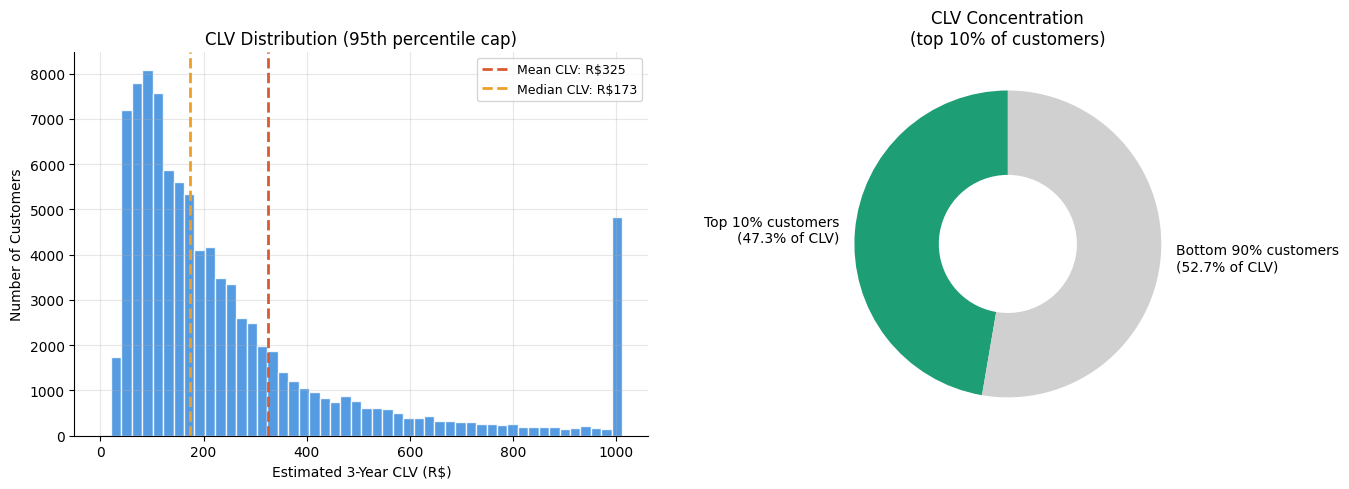

Chart saved!
Top 10% of customers account for 47.3% of total CLV
Threshold to be in top 10%: R$ 617.47 CLV


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLV distribution (capped for readability)
clv_cap = rfm_base['clv_estimate'].quantile(0.95)
clv_plot = rfm_base['clv_estimate'].clip(0, clv_cap)
axes[0].hist(clv_plot, bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(rfm_base['clv_estimate'].mean(), color=CORAL,
                linewidth=2, linestyle='--',
                label=f"Mean CLV: R${rfm_base['clv_estimate'].mean():.0f}")
axes[0].axvline(rfm_base['clv_estimate'].median(), color=AMBER,
                linewidth=2, linestyle='--',
                label=f"Median CLV: R${rfm_base['clv_estimate'].median():.0f}")
axes[0].set_title('CLV Distribution (95th percentile cap)', fontsize=12)
axes[0].set_xlabel('Estimated 3-Year CLV (R$)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=9)

# Top 10% vs bottom 90% revenue
threshold_90 = rfm_base['clv_estimate'].quantile(0.90)
top10pct     = rfm_base[rfm_base['clv_estimate'] >= threshold_90]
bot90pct     = rfm_base[rfm_base['clv_estimate'] <  threshold_90]
top10_clv_share = top10pct['clv_estimate'].sum() / rfm_base['clv_estimate'].sum() * 100

axes[1].pie(
    [top10pct['clv_estimate'].sum(), bot90pct['clv_estimate'].sum()],
    labels=[
        f'Top 10% customers\n({top10_clv_share:.1f}% of CLV)',
        f'Bottom 90% customers\n({100-top10_clv_share:.1f}% of CLV)'
    ],
    colors=[GREEN, '#d0d0d0'],
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=10)
)
axes[1].set_title('CLV Concentration\n(top 10% of customers)', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f'Top 10% of customers account for {top10_clv_share:.1f}% of total CLV')
print(f'Threshold to be in top 10%: R$ {threshold_90:.2f} CLV')

## 13. Chart 7 — RFM Scatter Plot (Recency vs Monetary)

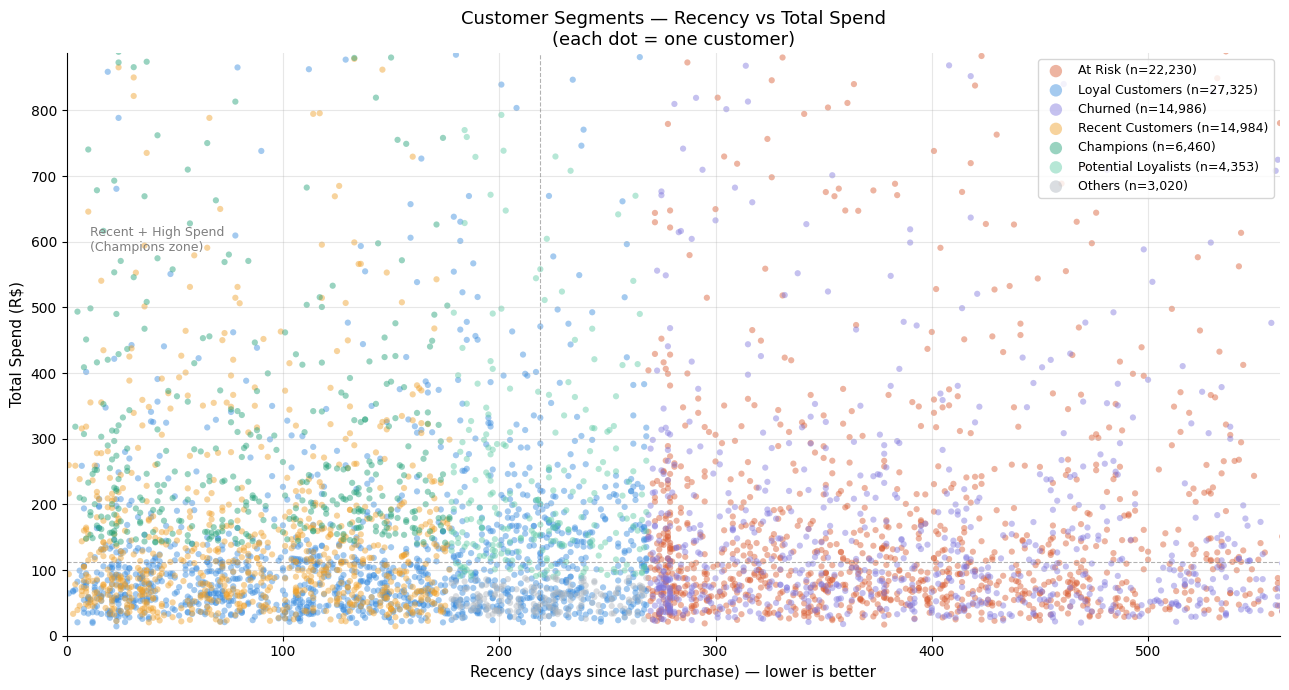

Chart saved!


In [13]:
sample = rfm_base.sample(n=min(5000, len(rfm_base)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 7))

for seg in seg_order:
    seg_data = sample[sample['segment'] == seg]
    ax.scatter(
        seg_data['recency'],
        seg_data['monetary'],
        c=SEGMENT_COLORS.get(seg, '#adb5bd'),
        label=f'{seg} (n={len(rfm_base[rfm_base["segment"]==seg]):,})',
        alpha=0.45,
        s=20,
        edgecolors='none'
    )

ax.set_xlabel('Recency (days since last purchase) — lower is better', fontsize=11)
ax.set_ylabel('Total Spend (R$)', fontsize=11)
ax.set_title('Customer Segments — Recency vs Total Spend\n(each dot = one customer)', fontsize=13)
ax.set_xlim(0, rfm_base['recency'].quantile(0.98))
ax.set_ylim(0, rfm_base['monetary'].quantile(0.97))
ax.legend(fontsize=9, markerscale=2, loc='upper right')

# Quadrant lines
r_mid = rfm_base['recency'].median()
m_mid = rfm_base['monetary'].median()
ax.axvline(r_mid, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(m_mid, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(r_mid * 0.05, rfm_base['monetary'].quantile(0.94),
        'Recent + High Spend\n(Champions zone)', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 14. Export RFM Table

In [14]:
# Save full RFM table
rfm_export = rfm_base[[
    'customer_unique_id', 'customer_state',
    'recency', 'frequency', 'monetary',
    'r_score', 'f_score', 'm_score', 'rfm_score',
    'segment', 'avg_order_value', 'clv_estimate', 'avg_review'
]].copy()

rfm_export.to_csv(OUTPUTS_PATH + 'rfm_customer_segments.csv', index=False)
print(f'RFM table exported: {rfm_export.shape}')
print('Saved to outputs/rfm_customer_segments.csv')

# Also save segment summary
segment_summary.to_csv(OUTPUTS_PATH + 'segment_summary.csv', index=False)
print('Segment summary saved to outputs/segment_summary.csv')

RFM table exported: (93358, 13)
Saved to outputs/rfm_customer_segments.csv
Segment summary saved to outputs/segment_summary.csv


## 15. Segment Action Plan — Business Recommendations

In [15]:
print('=' * 65)
print('    CUSTOMER SEGMENTATION — COMPLETE SUMMARY & ACTION PLAN')
print('=' * 65)

for _, row in segment_summary.sort_values('customer_count', ascending=False).iterrows():
    seg  = row['segment']
    cnt  = int(row['customer_count'])
    cpct = row['customer_pct']
    rpct = row['revenue_pct']
    clv  = clv_by_segment[clv_by_segment['segment']==seg]['avg_clv'].values[0]

    actions = {
        'Champions'          : 'Reward with VIP program, early access, referral incentives. Protect at all costs.',
        'Loyal Customers'    : 'Upsell premium categories. Send personalised product recommendations.',
        'Potential Loyalists': 'Offer a second-purchase discount. Trigger with email 30 days after first order.',
        'Recent Customers'   : 'Welcome series emails. Introduce product categories based on first purchase.',
        'At Risk'            : 'Win-back campaign: limited-time offer. Personalised "We miss you" outreach.',
        'Churned'            : 'Last-chance reactivation offer. If no response, remove from active marketing.',
        'Others'             : 'Monitor. Classify further as data accumulates.'
    }

    print(f"""
  [{seg}]
  Customers : {cnt:,} ({cpct:.1f}% of base)
  Revenue   : {rpct:.1f}% of total revenue
  Avg CLV   : R$ {clv:.0f}
  Action    : {actions.get(seg, 'N/A')}
  {'-'*60}""")

print(f"""
  OVERALL METRICS
  Total customers        : {len(rfm_base):,}
  Repeat purchase rate   : {repeat_rate:.2f}%
  Avg CLV (all customers): R$ {rfm_base['clv_estimate'].mean():,.0f}
  Total estimated CLV    : R$ {rfm_base['clv_estimate'].sum():,.0f}

  CHARTS SAVED TO outputs/
  rfm_segment_overview.png
  rfm_dimension_boxplots.png
  rfm_heatmap.png
  rfm_loyalty_analysis.png
  clv_by_segment.png
  clv_distribution.png
  rfm_scatter.png
  rfm_customer_segments.csv
  segment_summary.csv
""")
print('=' * 65)
print('Next → Notebook 05: Machine Learning Models')
print('=' * 65)

    CUSTOMER SEGMENTATION — COMPLETE SUMMARY & ACTION PLAN

  [Loyal Customers]
  Customers : 27,325 (29.3% of base)
  Revenue   : 22.9% of total revenue
  Avg CLV   : R$ 254
  Action    : Upsell premium categories. Send personalised product recommendations.
  ------------------------------------------------------------

  [At Risk]
  Customers : 22,230 (23.8% of base)
  Revenue   : 23.8% of total revenue
  Avg CLV   : R$ 326
  Action    : Win-back campaign: limited-time offer. Personalised "We miss you" outreach.
  ------------------------------------------------------------

  [Churned]
  Customers : 14,986 (16.1% of base)
  Revenue   : 16.3% of total revenue
  Avg CLV   : R$ 330
  Action    : Last-chance reactivation offer. If no response, remove from active marketing.
  ------------------------------------------------------------

  [Recent Customers]
  Customers : 14,984 (16.1% of base)
  Revenue   : 15.5% of total revenue
  Avg CLV   : R$ 314
  Action    : Welcome series emails. 

---
## Next Step → Notebook 05: Machine Learning Models

```python
master = pd.read_csv('../data/master_olist.csv')
rfm    = pd.read_csv('../outputs/rfm_customer_segments.csv')
```